# 🎵 Spotify Recommendation System
### Based on actual data audit of `data.csv`

**Dataset facts (verified from real file):**
- 170,653 songs × 19 columns
- Years: 1921 – 2020
- **No null values** in any column
- **12,968 duplicate (name+artist) pairs** → need deduplication
- `artists` column is a **string that looks like a Python list** e.g. `"['Ed Sheeran', 'Justin Bieber']"`
- `release_date` has **mixed formats**: some `YYYY`, some `YYYY-MM-DD`
- **27,892 songs** have `popularity = 0` (obscure/unlisted tracks)
- **143 songs** have `tempo = 0` (bad data)
- **177 songs** shorter than 30 seconds (intros/skits)
- **110 songs** longer than 30 minutes (live sets/compilations)
- **91 songs** with loudness < -40 dB (silence/near-silence)


## ⚙️ Step 1: Install & Import

In [56]:
%pip install -q scikit-learn joblib prophet seaborn matplotlib jinja2 plotly google ipywidgets


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import warnings
warnings.filterwarnings("ignore")

import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("darkgrid")
plt.rcParams["figure.dpi"] = 120
print("✅ Libraries ready")

✅ Libraries ready


## 📥 Step 2: Upload Dataset
Upload your `data.csv` file here.

## 🔍 Step 3: Load & Audit Raw Data
Always inspect before touching anything.

In [15]:
df_raw = pd.read_csv("data.csv")

print(f"Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumns:\n{df_raw.columns.tolist()}")
print(f"\nDtypes:")
print(df_raw.dtypes)
df_raw.head(3)

Shape : 170,653 rows × 19 columns

Columns:
['valence', 'year', 'acousticness', 'artists', 'danceability', 'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date', 'speechiness', 'tempo']

Dtypes:
valence             float64
year                  int64
acousticness        float64
artists                 str
danceability        float64
duration_ms           int64
energy              float64
explicit              int64
id                      str
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
name                    str
popularity            int64
release_date            str
speechiness         float64
tempo               float64
dtype: object


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339


In [16]:
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df_raw.isnull().sum())

print("\n" + "=" * 50)
print("DUPLICATES")
print("=" * 50)
print(f"Exact duplicate rows        : {df_raw.duplicated().sum():,}")
print(f"Duplicate (name + artists)  : {df_raw.duplicated(subset=['name','artists']).sum():,}")
print(f"Duplicate track id          : {df_raw['id'].duplicated().sum():,}")

print("\n" + "=" * 50)
print("KNOWN DATA ISSUES (from audit)")
print("=" * 50)
print(f"popularity = 0              : {(df_raw['popularity']==0).sum():,}")
print(f"tempo = 0                   : {(df_raw['tempo']==0).sum():,}")
print(f"duration < 30s (<30000ms)   : {(df_raw['duration_ms']<30000).sum():,}")
print(f"duration > 30min (>1800000) : {(df_raw['duration_ms']>1800000).sum():,}")
print(f"loudness < -40 dB           : {(df_raw['loudness']<-40).sum():,}")
print(f"loudness > 0 dB             : {(df_raw['loudness']>0).sum():,}")

print("\n" + "=" * 50)
print("ARTISTS FORMAT (string-encoded list)")
print("=" * 50)
print(df_raw["artists"].head(5).tolist())

MISSING VALUES
valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64

DUPLICATES
Exact duplicate rows        : 0
Duplicate (name + artists)  : 12,968
Duplicate track id          : 0

KNOWN DATA ISSUES (from audit)
popularity = 0              : 27,892
tempo = 0                   : 143
duration < 30s (<30000ms)   : 177
duration > 30min (>1800000) : 110
loudness < -40 dB           : 91
loudness > 0 dB             : 31

ARTISTS FORMAT (string-encoded list)
["['Sergei Rachmaninoff', 'James Levine', 'Berliner Philharmoniker']", "['Dennis Day']", "['KHP Kridhamardawa Karaton Ngayogyakarta Hadiningrat']", "['Frank Parker']"

## 🔧 Step 4: Preprocessing
Every decision below is based on what the audit actually found.

In [17]:
df = df_raw.copy()
print(f"Start : {len(df):,} rows")

# ── 1. Parse artists from string-encoded list to clean string ──
# Audit found: artists stored as "['Ed Sheeran', 'Justin Bieber']" (a string, not a list)
def parse_artists(val):
    try:
        lst = ast.literal_eval(val)   # safely parse the string as a Python list
        return ", ".join(lst)         # join multiple artists with comma
    except Exception:
        return str(val).strip("[]'\"")

df["artists_clean"] = df["artists"].apply(parse_artists)
print("\nSample parsed artists:")
print(df[["artists", "artists_clean"]].head(4).to_string())

Start : 170,653 rows

Sample parsed artists:
                                                              artists                                               artists_clean
0  ['Sergei Rachmaninoff', 'James Levine', 'Berliner Philharmoniker']  Sergei Rachmaninoff, James Levine, Berliner Philharmoniker
1                                                      ['Dennis Day']                                                  Dennis Day
2             ['KHP Kridhamardawa Karaton Ngayogyakarta Hadiningrat']         KHP Kridhamardawa Karaton Ngayogyakarta Hadiningrat
3                                                    ['Frank Parker']                                                Frank Parker


In [18]:
# ── 2. Fix release_date mixed format → extract year reliably ──
# Audit found: some rows have '1921', others have '1921-03-20'
# We already have 'year' column (int) which is always clean — use that directly
# Confirm year column is already correct:
print("year column range:", df["year"].min(), "–", df["year"].max())
print("year dtype:", df["year"].dtype)
# ✅ year column is clean int — no conversion needed

year column range: 1921 – 2020
year dtype: int64


In [19]:
# ── 3. Remove duplicate (name + artists) — keep highest popularity ──
# Audit found: 12,968 duplicate (name+artists) pairs with different ids
# Strategy: keep the version with the highest popularity score
before = len(df)
df = df.sort_values("popularity", ascending=False)
df = df.drop_duplicates(subset=["name", "artists"], keep="first")
df = df.reset_index(drop=True)
print(f"Dropped duplicates (name+artists): {before - len(df):,} rows removed")
print(f"Remaining: {len(df):,} rows")

Dropped duplicates (name+artists): 12,968 rows removed
Remaining: 157,685 rows


In [20]:
# ── 4. Remove bad audio data ──────────────────────────────────
# Audit found real issues — these are not valid songs for recommendation
before = len(df)

# tempo = 0 → 143 rows — Spotify failed to detect BPM, unusable for audio similarity
df = df[df["tempo"] > 0]

# duration < 30 seconds → 177 rows — intros, skits, sound effects
df = df[df["duration_ms"] >= 30000]

# duration > 30 minutes → 110 rows — live sets, compilations, not single songs
df = df[df["duration_ms"] <= 1800000]

# loudness < -40 dB → 91 rows — essentially silence, bad recordings
df = df[df["loudness"] >= -40]

print(f"Removed bad audio rows: {before - len(df):,}")
print(f"Remaining: {len(df):,} rows")

Removed bad audio rows: 437
Remaining: 157,248 rows


In [21]:
# ── 5. Handle popularity = 0 ─────────────────────────────────
# Audit found: 27,892 songs with popularity = 0
# These ARE valid songs — just unpopular or delisted from Spotify
# Decision: KEEP them for the audio feature models (KNN, clustering)
#           but FLAG them so users know recommendations may be obscure
print(f"Songs with popularity = 0: {(df['popularity'] == 0).sum():,}")
print("→ Keeping all — they have valid audio features")
print("→ Adding 'is_obscure' flag for transparency")
df["is_obscure"] = (df["popularity"] == 0).astype(int)

Songs with popularity = 0: 25,999
→ Keeping all — they have valid audio features
→ Adding 'is_obscure' flag for transparency


In [22]:
# ── 6. Convert duration_ms → duration_min for readability ────
df["duration_min"] = (df["duration_ms"] / 60000).round(2)

# ── 7. Convert explicit 0/1 → bool for clarity ───────────────
df["explicit"] = df["explicit"].astype(bool)

df = df.reset_index(drop=True)

print(f"\n✅ Final clean dataset: {len(df):,} songs")
print(f"Columns: {df.columns.tolist()}")
df.head(3)


✅ Final clean dataset: 157,248 songs
Columns: ['valence', 'year', 'acousticness', 'artists', 'danceability', 'duration_ms', 'energy', 'explicit', 'id', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'name', 'popularity', 'release_date', 'speechiness', 'tempo', 'artists_clean', 'is_obscure', 'duration_min']


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,...,loudness,mode,name,popularity,release_date,speechiness,tempo,artists_clean,is_obscure,duration_min
0,0.145,2020,0.4010,"['Bad Bunny', 'Jhay Cortez']",0.731,205090,0.573,True,47EiUVwUp4C9fGccaPuUCS,0.000052,...,-10.059,0,Dakiti,100,2020-10-30,0.0544,109.928,"Bad Bunny, Jhay Cortez",0,3.42
1,0.756,2020,0.2210,"['24kGoldn', 'iann dior']",0.700,140526,0.722,True,3tjFYV6RSFtuktYl3ZtYcq,0.000000,...,-3.558,0,Mood (feat. iann dior),99,2020-07-24,0.0369,90.989,"24kGoldn, iann dior",0,2.34
2,0.737,2020,0.0112,['BTS'],0.746,199054,0.765,False,0t1kP63rueHleOhQkYSXFY,0.000000,...,-4.410,0,Dynamite,97,2020-08-28,0.0993,114.044,BTS,0,3.32


In [23]:
# ── 8. Define feature sets ────────────────────────────────────

# These are the actual audio features in this dataset (verified from audit)
AUDIO_FEATURES = [
    "acousticness",    # float [0,1]   — how acoustic the track is
    "danceability",    # float [0,1]   — how suitable for dancing
    "energy",          # float [0,1]   — intensity and activity
    "instrumentalness",# float [0,1]   — predicts absence of vocals
    "liveness",        # float [0,1]   — presence of live audience
    "loudness",        # float [-60,0] — overall loudness in dB  ← needs scaling
    "speechiness",     # float [0,1]   — spoken words presence
    "tempo",           # float [0,244] — BPM                     ← needs scaling
    "valence",         # float [0,1]   — musical positiveness
]

# key (0-11) and mode (0/1) are categorical — handle separately
# duration_ms — not an audio quality feature, excluded from similarity
# popularity  — user behaviour metric, not intrinsic audio feature
# year        — temporal, not audio

print("Audio features for models:", AUDIO_FEATURES)
print("\nNote: loudness and tempo are NOT in [0,1] — will be normalized")

Audio features for models: ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

Note: loudness and tempo are NOT in [0,1] — will be normalized


In [24]:
# ── 9. Normalize audio features to [0, 1] ────────────────────
# loudness ranges [-60, 3.8] and tempo [0, 243] — must normalize
# All others are already [0,1] but we normalize uniformly for consistency

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[AUDIO_FEATURES] = scaler.fit_transform(df[AUDIO_FEATURES])

print("After normalization — all features should be in [0, 1]:")
print(df_scaled[AUDIO_FEATURES].min().round(4).to_frame("min").T)
print(df_scaled[AUDIO_FEATURES].max().round(4).to_frame("max").T)

After normalization — all features should be in [0, 1]:
     acousticness  danceability  energy  instrumentalness  liveness  loudness  \
min           0.0           0.0     0.0               0.0       0.0       0.0   

     speechiness  tempo  valence  
min          0.0    0.0      0.0  
     acousticness  danceability  energy  instrumentalness  liveness  loudness  \
max           1.0           1.0     1.0               1.0       1.0       1.0   

     speechiness  tempo  valence  
max          1.0    1.0      1.0  


## 📊 Step 5: EDA

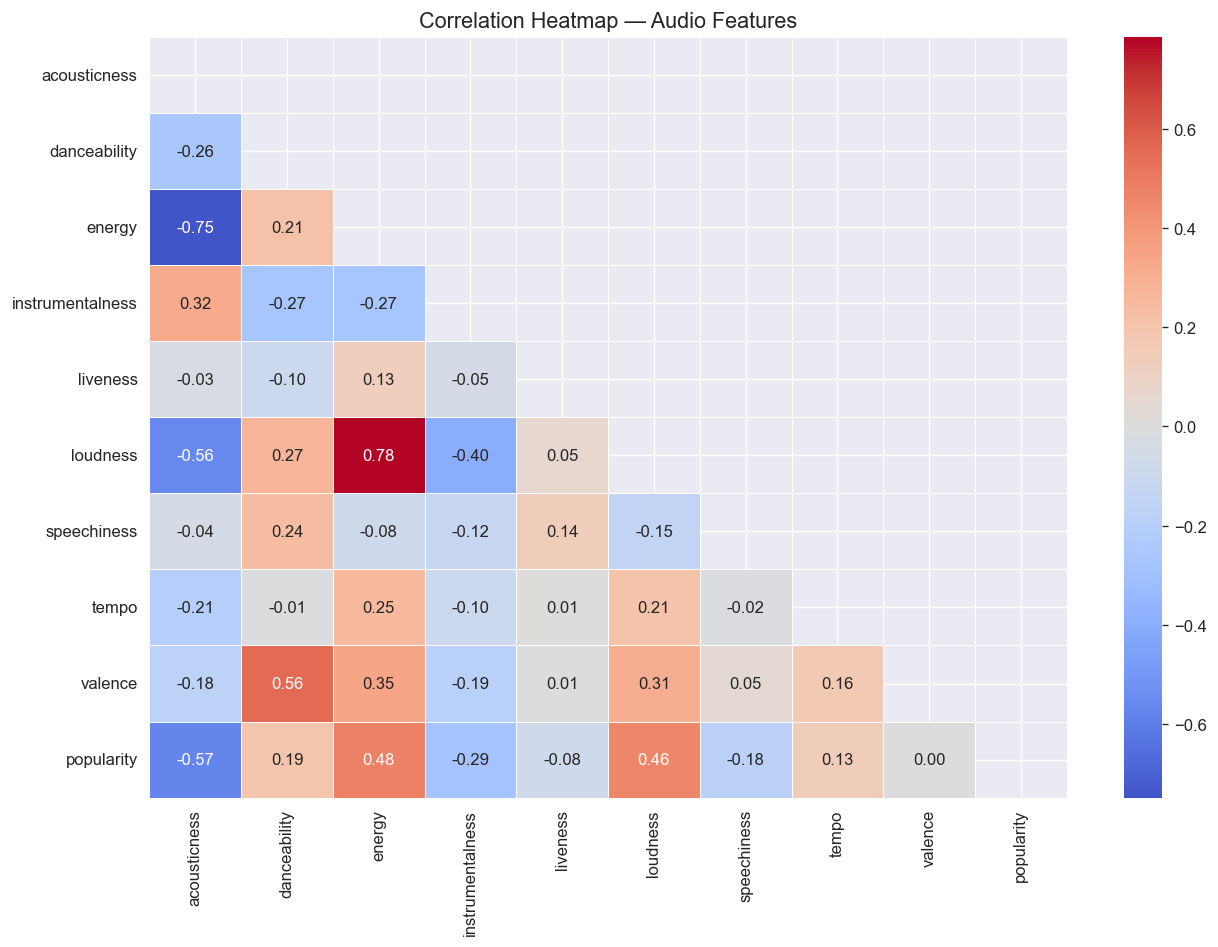

In [25]:
# ── Correlation heatmap ───────────────────────────────────────
plt.figure(figsize=(11, 8))
corr = df[AUDIO_FEATURES + ["popularity"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Audio Features", fontsize=13)
plt.tight_layout()
plt.show()

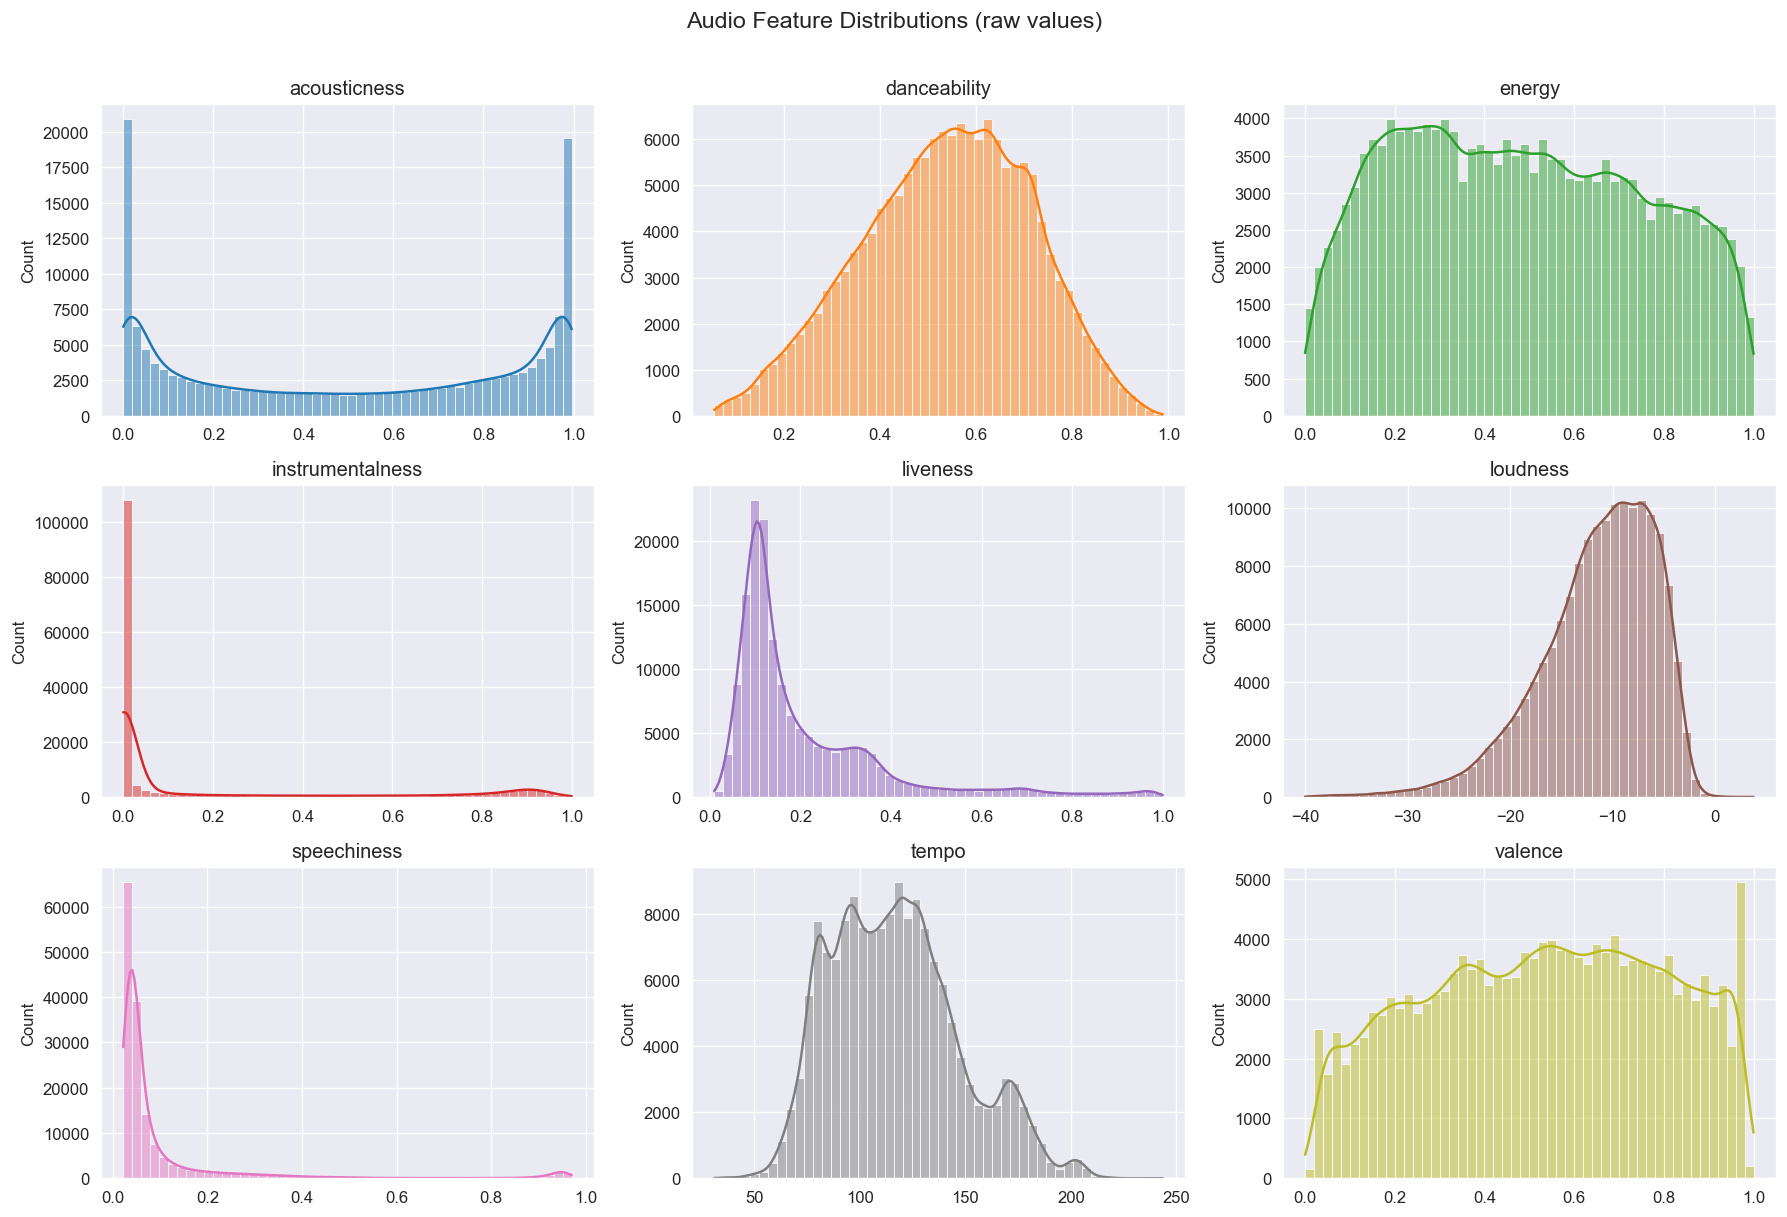

In [26]:
# ── Feature distributions ─────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
colors = sns.color_palette("tab10", len(AUDIO_FEATURES))

for i, feat in enumerate(AUDIO_FEATURES):
    sns.histplot(df[feat], bins=50, kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(feat)
    axes[i].set_xlabel("")

plt.suptitle("Audio Feature Distributions (raw values)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

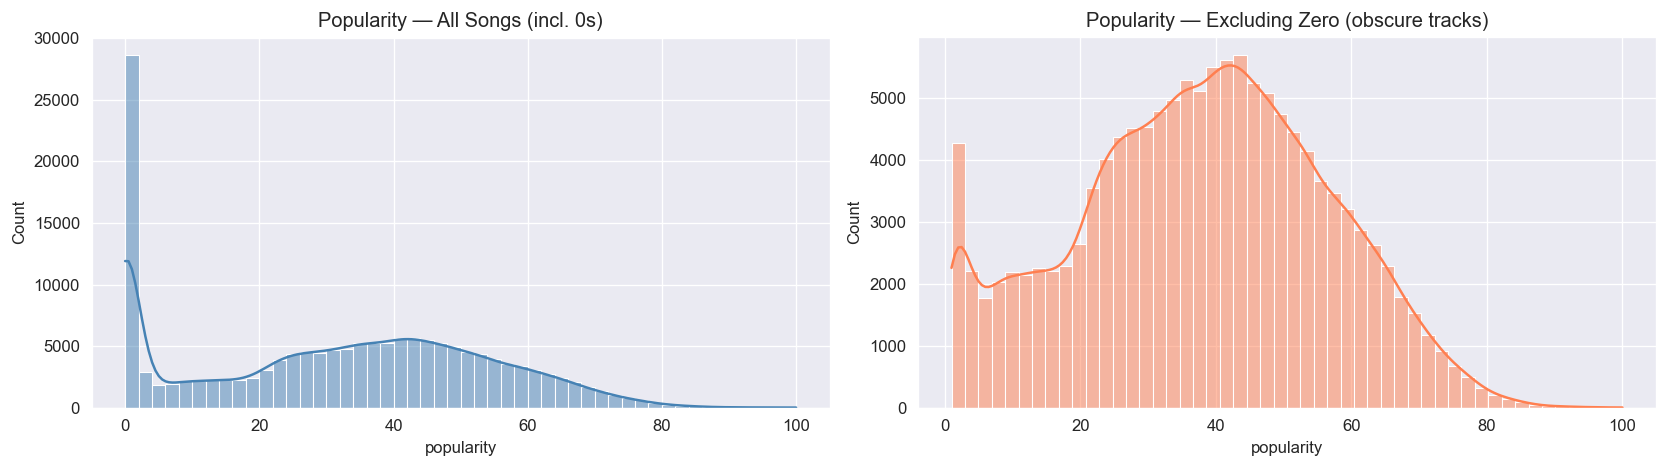

Songs with popularity > 0: 131,249
Songs with popularity = 0: 25,999


In [27]:
# ── Popularity distribution ───────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["popularity"], bins=50, kde=True, ax=ax1, color="steelblue")
ax1.set_title("Popularity — All Songs (incl. 0s)")

sns.histplot(df[df["popularity"] > 0]["popularity"], bins=50,
             kde=True, ax=ax2, color="coral")
ax2.set_title("Popularity — Excluding Zero (obscure tracks)")

plt.tight_layout()
plt.show()

print(f"Songs with popularity > 0: {(df['popularity'] > 0).sum():,}")
print(f"Songs with popularity = 0: {(df['popularity'] == 0).sum():,}")

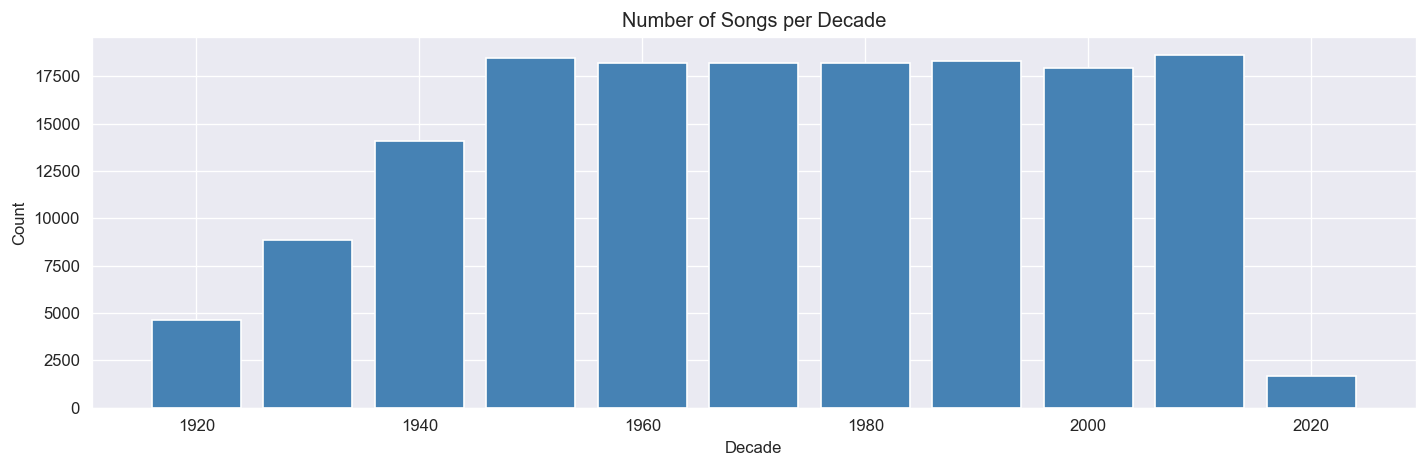

In [28]:
# ── Songs per decade ─────────────────────────────────────────
df["decade"] = (df["year"] // 10) * 10
decade_counts = df.groupby("decade").size().reset_index(name="count")

plt.figure(figsize=(12, 4))
plt.bar(decade_counts["decade"], decade_counts["count"], width=8, color="steelblue")
plt.title("Number of Songs per Decade")
plt.xlabel("Decade")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

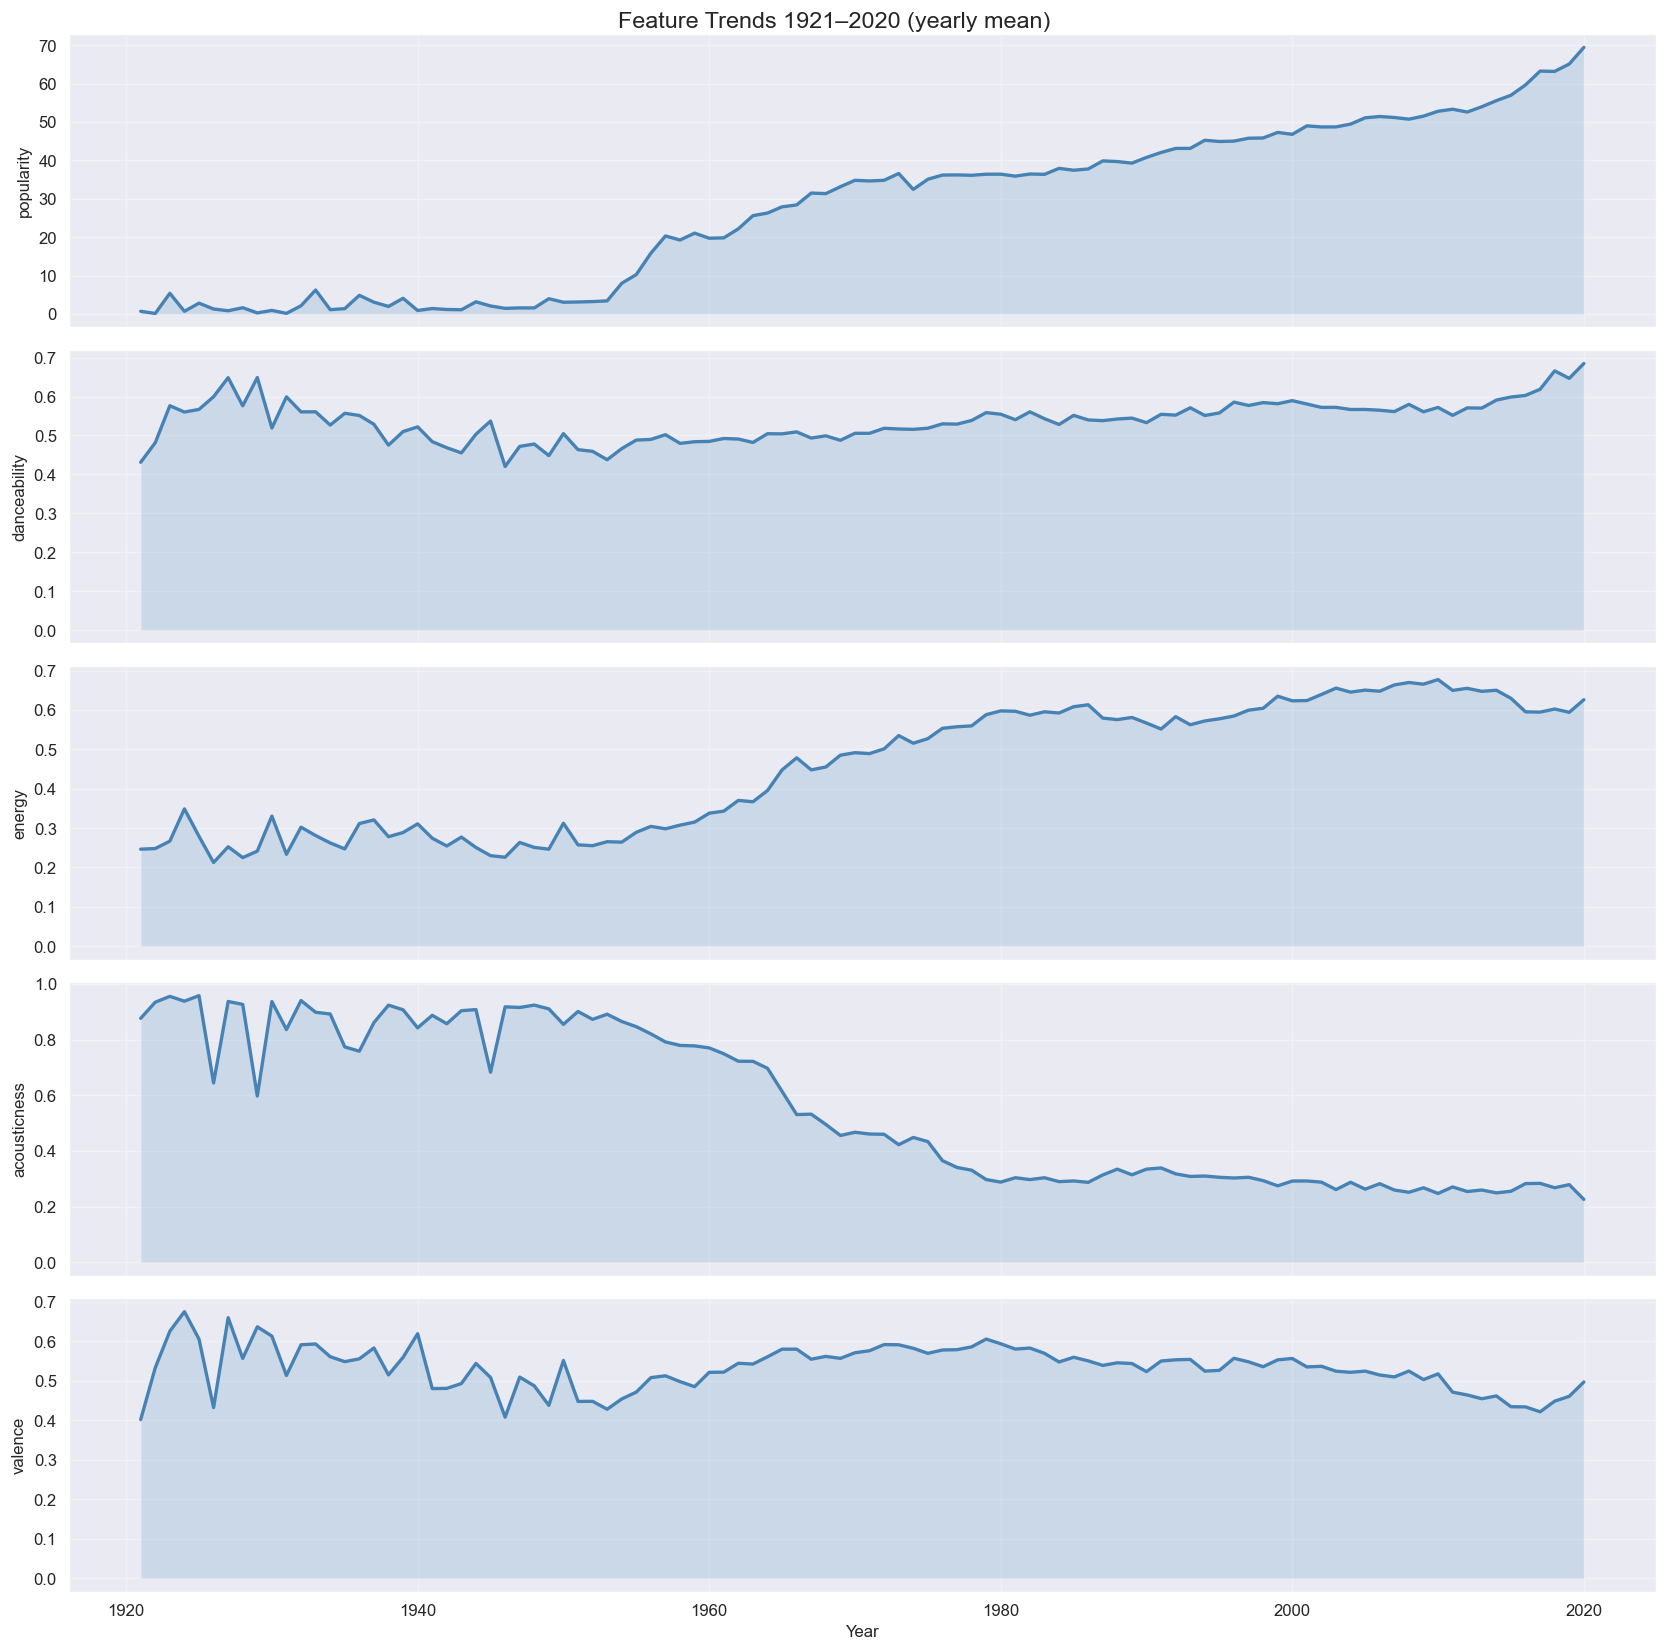

In [29]:
# ── Audio feature trends over time ────────────────────────────
trend_features = ["popularity", "danceability", "energy", "acousticness", "valence"]
yearly = df.groupby("year")[trend_features].mean()

fig, axes = plt.subplots(len(trend_features), 1, figsize=(14, 14), sharex=True)
for ax, feat in zip(axes, trend_features):
    ax.plot(yearly.index, yearly[feat], linewidth=2, color="steelblue")
    ax.fill_between(yearly.index, yearly[feat], alpha=0.15)
    ax.set_ylabel(feat)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("Year")
plt.suptitle("Feature Trends 1921–2020 (yearly mean)", fontsize=14)
plt.tight_layout()
plt.show()

## 🎧 Step 6: Model 1 — Content-Based KNN

In [30]:
print(f"Training KNN on {len(df_scaled):,} songs with {len(AUDIO_FEATURES)} features...")

X = df_scaled[AUDIO_FEATURES].values

knn_model = NearestNeighbors(
    n_neighbors=11,    # 10 recs + 1 (the query song itself)
    metric="cosine",   # best for normalised audio feature vectors
    algorithm="brute", # required for cosine metric
    n_jobs=-1
)
knn_model.fit(X)
print("✅ KNN trained!")

Training KNN on 157,248 songs with 9 features...
✅ KNN trained!


In [33]:
def recommend_songs(song_name, df_scaled, knn_model, n=10, popular_only=False):
    """
    Recommend songs similar to a given song using KNN cosine similarity.

    Parameters
    ----------
    song_name    : str   — full or partial song name (case-insensitive)
    df_scaled    : DataFrame — the normalized dataset
    knn_model    : trained NearestNeighbors model
    n            : int   — number of recommendations
    popular_only : bool  — if True, exclude popularity=0 songs from results

    Output
    ------
    DataFrame with: name, artists_clean, year, popularity, similarity_score
    """
    matches = df_scaled[
        df_scaled["name"].str.lower().str.contains(song_name.lower(), na=False)
    ]

    if matches.empty:
        print(f"❌ '{song_name}' not found. Try a partial name.")
        return None

    song = matches.iloc[0]
    print(f"\n🎧 Query  : '{song['name']}'")
    print(f"   Artist : {song['artists_clean']}")
    print(f"   Year   : {song['year']}")
    print(f"   Pop    : {song['popularity']}")
    print("-" * 55)

    query = song[AUDIO_FEATURES].values.reshape(1, -1)
    distances, indices = knn_model.kneighbors(query)

    results = df_scaled.iloc[indices[0][1:]].copy()   # skip index 0 = the song itself
    results["similarity_score"] = (1 - distances[0][1:]).round(4)

    if popular_only:
        results = results[results["popularity"] > 0]

    return results.head(n)[
        ["name", "artists_clean", "year", "popularity", "similarity_score"]
    ].reset_index(drop=True)


# ── Try it ───────────────────────────────────────────────────
recs = recommend_songs("Shape of You", df_scaled, knn_model, n=10)
if recs is not None:
    display(recs.style.background_gradient(subset=["similarity_score"], cmap="Greens"))


🎧 Query  : 'Shape of You'
   Artist : Ed Sheeran
   Year   : 2017
   Pop    : 85
-------------------------------------------------------


,name,artists_clean,year,popularity,similarity_score
0,Let Me Luv Your Girl,Mr. Capone-E,2007,41,0.999700
1,You Are The One,The Whispers,1990,27,0.999300
2,"Si Te Vas, Te Vas",Jeanette,1981,31,0.999200
3,Así Se Compone Un Son,"Ismael Miranda, Orquesta Revelación",1973,47,0.999100
4,Gripa Colombiana,Los Tucanes De Tijuana,2000,54,0.999000
5,Vida Ventajosa,Los Dos Carnales,2019,74,0.999000
6,Bananaphone,Raffi,1994,54,0.999000
7,Brujeria,El Gran Combo De Puerto Rico,1979,58,0.999000
8,Back To The Barrooms Again - Live At Anaheim,Merle Haggard,1980,21,0.998900
9,Eenie Meenie,Jeffrey Osborne,1982,38,0.998700


In [34]:
# ── Change song name here ────────────────────────────────────
MY_SONG = "Blinding Lights"    # 👈 change this

recs = recommend_songs(MY_SONG, df_scaled, knn_model, n=10, popular_only=True)
if recs is not None:
    display(recs.style.background_gradient(subset=["similarity_score"], cmap="Blues"))


🎧 Query  : 'Blinding Lights'
   Artist : The Weeknd
   Year   : 2020
   Pop    : 96
-------------------------------------------------------


,name,artists_clean,year,popularity,similarity_score
0,"Edge of Great (feat. Madison Reyes, Charlie Gillespie, Owen Patrick Joyner & Jeremy Shada)","Julie and the Phantoms Cast, Madison Reyes, Charlie Gillespie, Owen Patrick Joyner, Jeremy Shada",2020,72,0.999300
1,Dead Man Walking,Jeremy Camp,2019,59,0.999200
2,Be Happy - Remix,"Dixie D’Amelio, blackbear, Lil Mosey",2020,73,0.999200
3,Latin Simone (Que Pasa Contigo),Gorillaz,2001,45,0.999100
4,You're Gonna Miss This,Trace Adkins,2007,63,0.999000
5,POP/STARS,"K/DA, Madison Beer, (G)I-DLE, Jaira Burns, League of Legends",2018,79,0.998900
6,Thief,Ansel Elgort,2017,62,0.998700
7,Photograph,The Verve Pipe,1996,34,0.998600
8,Girls Like You,Miguel,2010,48,0.998600
9,Danger Line,Avenged Sevenfold,2010,57,0.998400


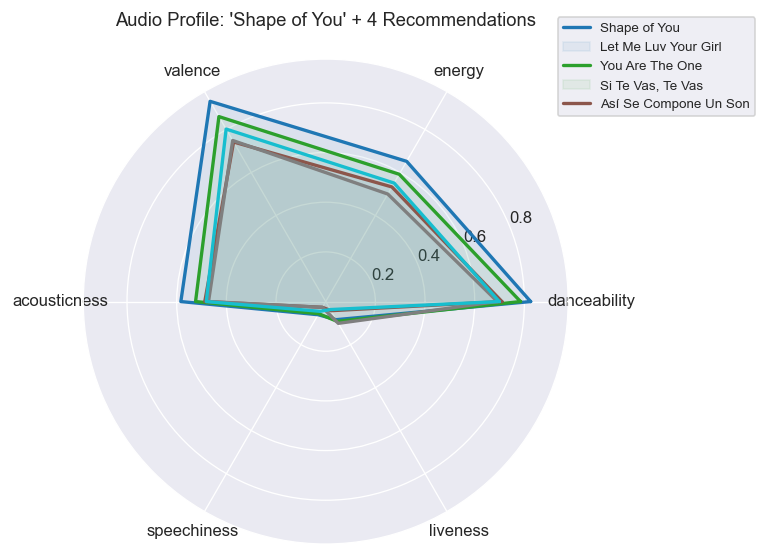

In [35]:
# ── Radar chart: query song vs top 4 recommendations ─────────
def radar_chart(song_name, df_scaled, knn_model):
    RADAR_FEATS = ["danceability", "energy", "valence",
                   "acousticness", "speechiness", "liveness"]
    matches = df_scaled[df_scaled["name"].str.lower().str.contains(
                        song_name.lower(), na=False)]
    if matches.empty:
        print("Song not found"); return

    song = matches.iloc[0]
    query = song[AUDIO_FEATURES].values.reshape(1, -1)
    distances, indices = knn_model.kneighbors(query)
    top5 = df_scaled.iloc[indices[0][:5]]

    N = len(RADAR_FEATS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + \
             [0]  # close the polygon

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    colors = plt.cm.tab10(np.linspace(0, 1, 5))

    for (_, row), color in zip(top5.iterrows(), colors):
        vals = row[RADAR_FEATS].tolist() + [row[RADAR_FEATS[0]]]
        ax.plot(angles, vals, color=color, linewidth=2)
        ax.fill(angles, vals, color=color, alpha=0.07)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_FEATS, fontsize=10)
    labels = [top5.iloc[0]["name"]] + \
             [top5.iloc[i]["name"] for i in range(1, 5)]
    ax.legend(labels, loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)
    ax.set_title(f"Audio Profile: '{song['name']}' + 4 Recommendations",
                 fontsize=11, pad=20)
    plt.tight_layout()
    plt.show()


radar_chart("Shape of You", df_scaled, knn_model)

## 🔵 Step 7: Model 2 — K-Means Clustering

Finding optimal K... (~1-2 min)
  K= 4 | Inertia:       39,999 | Silhouette: 0.2081
  K= 5 | Inertia:       35,600 | Silhouette: 0.2645
  K= 6 | Inertia:       31,056 | Silhouette: 0.2258
  K= 7 | Inertia:       28,752 | Silhouette: 0.2372
  K= 8 | Inertia:       27,337 | Silhouette: 0.2197
  K= 9 | Inertia:       25,925 | Silhouette: 0.2150
  K=10 | Inertia:       24,080 | Silhouette: 0.2092
  K=11 | Inertia:       22,695 | Silhouette: 0.2151
  K=12 | Inertia:       22,478 | Silhouette: 0.1945
  K=13 | Inertia:       21,891 | Silhouette: 0.1976
  K=14 | Inertia:       21,165 | Silhouette: 0.1850
  K=15 | Inertia:       20,309 | Silhouette: 0.1968


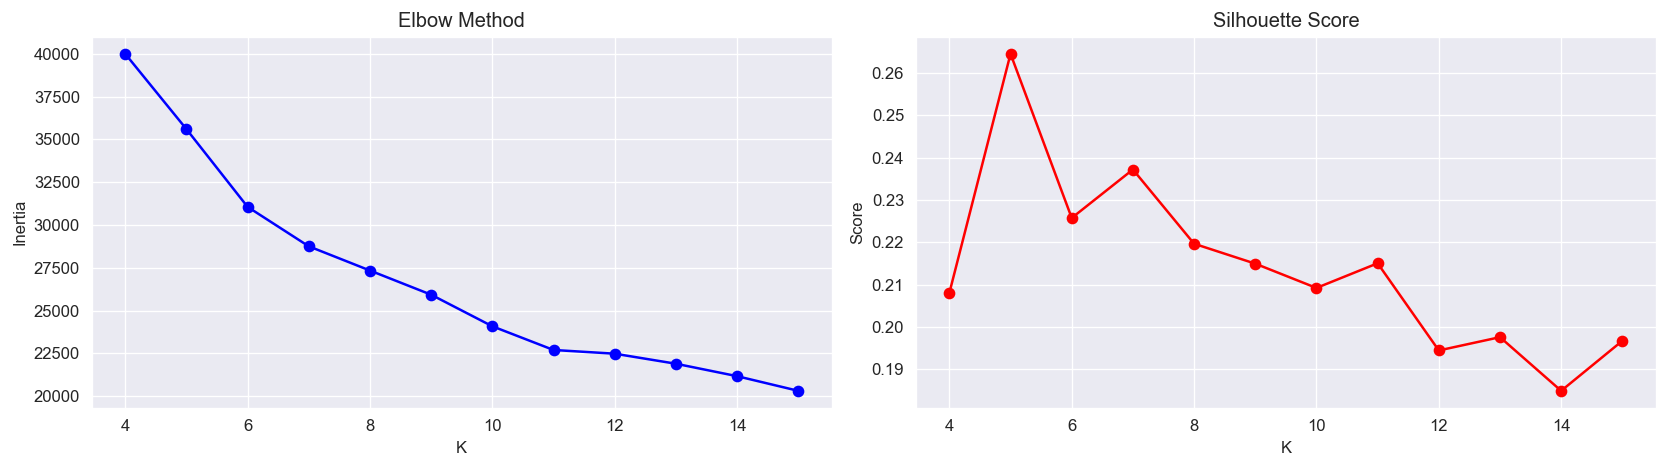


🏆 Best K = 5


In [36]:
# ── Find optimal K via Elbow + Silhouette ─────────────────────
print("Finding optimal K... (~1-2 min)")

X = df_scaled[AUDIO_FEATURES].values
k_range = range(4, 16)
inertias, silhouettes = [], []

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels, sample_size=8000, random_state=42)
    silhouettes.append(sil)
    print(f"  K={k:2d} | Inertia: {km.inertia_:>12,.0f} | Silhouette: {sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(list(k_range), inertias, "bo-")
ax1.set(title="Elbow Method", xlabel="K", ylabel="Inertia")
ax2.plot(list(k_range), silhouettes, "ro-")
ax2.set(title="Silhouette Score", xlabel="K", ylabel="Score")
plt.tight_layout()
plt.show()

BEST_K = list(k_range)[np.argmax(silhouettes)]
print(f"\n🏆 Best K = {BEST_K}")

In [37]:
# ── Train K-Means ────────────────────────────────────────────
kmeans_model = MiniBatchKMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df_clustered = df_scaled.copy()
df_clustered["cluster"] = kmeans_model.fit_predict(X)

print("✅ Clustering done!")
print("\nCluster sizes:")
print(df_clustered["cluster"].value_counts().sort_index())

✅ Clustering done!

Cluster sizes:
cluster
0    64699
1    23155
2    31507
3    32609
4     5278
Name: count, dtype: int64


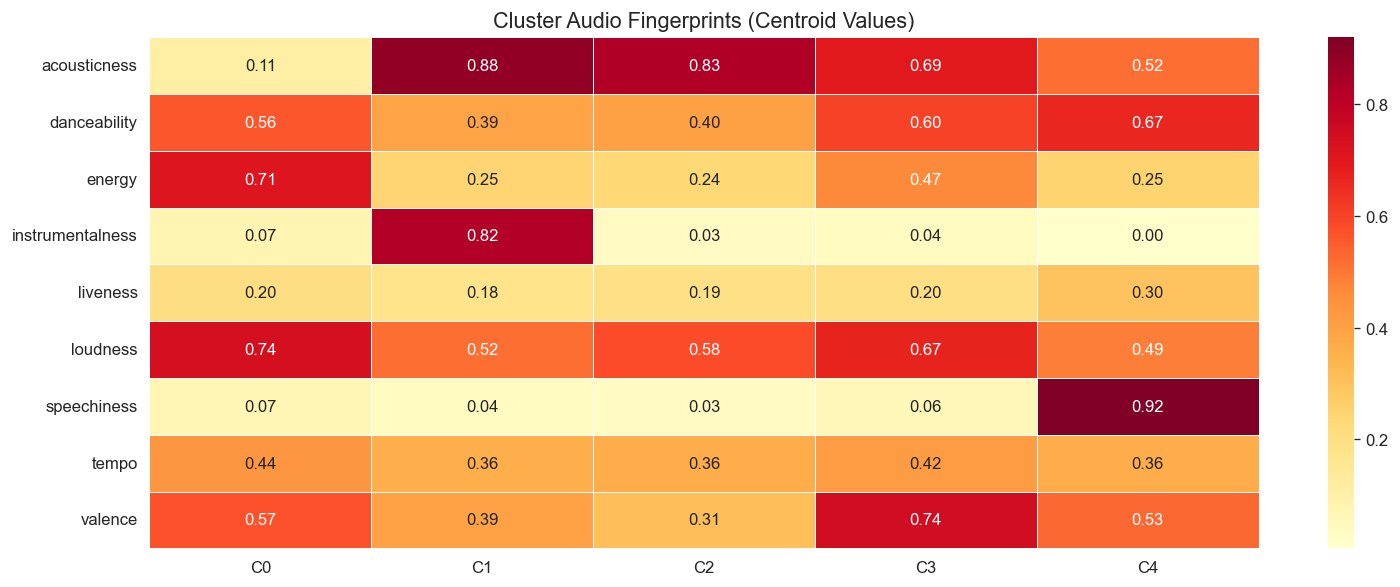

In [38]:
# ── Cluster fingerprints heatmap ─────────────────────────────
centers = pd.DataFrame(kmeans_model.cluster_centers_, columns=AUDIO_FEATURES)

plt.figure(figsize=(13, 5))
sns.heatmap(centers.T, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5,
            xticklabels=[f"C{i}" for i in range(BEST_K)])
plt.title("Cluster Audio Fingerprints (Centroid Values)", fontsize=13)
plt.tight_layout()
plt.show()

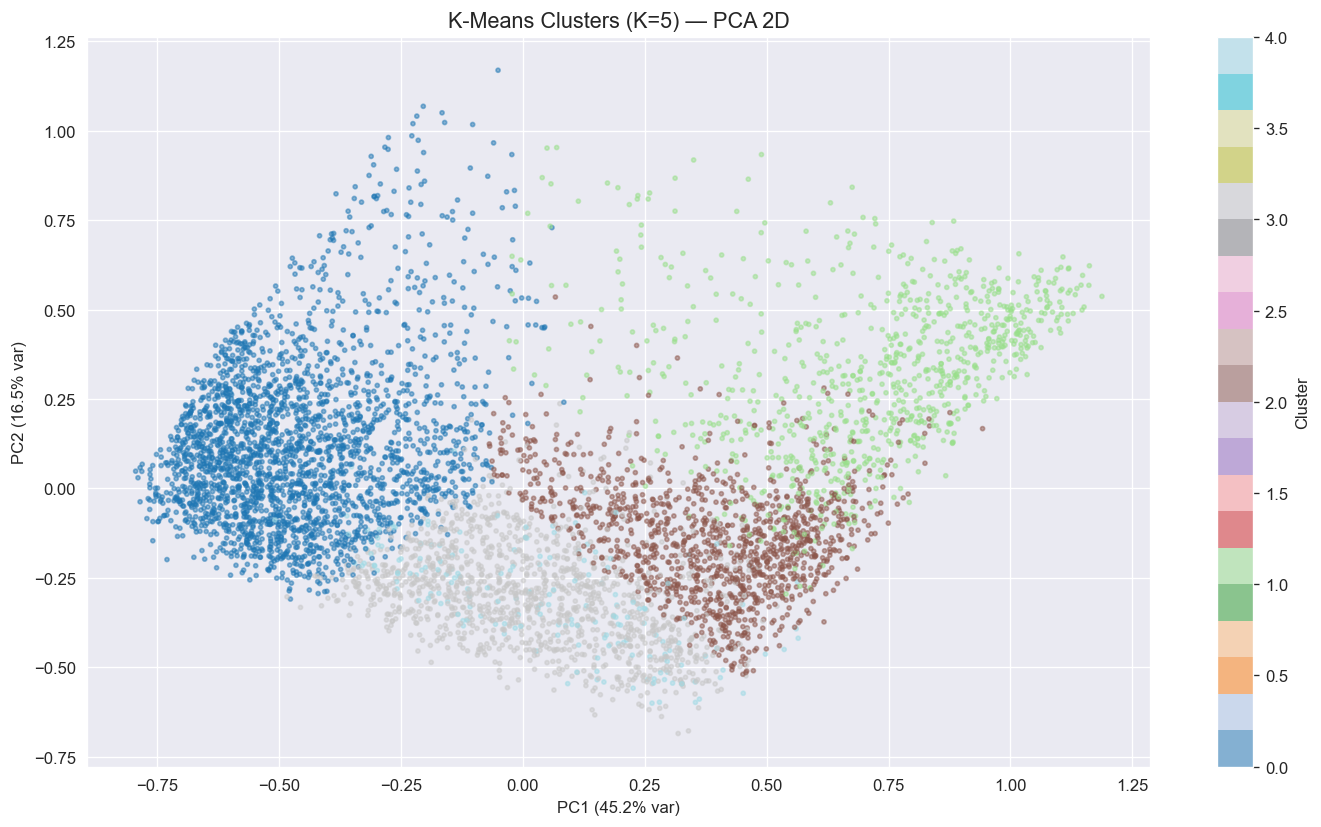

In [39]:
# ── PCA 2D cluster visualization ─────────────────────────────
sample = df_clustered.sample(min(6000, len(df_clustered)), random_state=42)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(sample[AUDIO_FEATURES].values)

plt.figure(figsize=(12, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1],
                      c=sample["cluster"], cmap="tab20",
                      alpha=0.5, s=6)
plt.colorbar(scatter, label="Cluster")
plt.title(f"K-Means Clusters (K={BEST_K}) — PCA 2D", fontsize=13)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.show()

In [40]:
def recommend_from_cluster(song_name, df_clustered, n=10, popular_only=True):
    """
    Find a song's cluster → return top-N popular songs from same cluster.

    Parameters
    ----------
    song_name    : str
    df_clustered : DataFrame with 'cluster' column
    n            : int
    popular_only : bool — if True, skip popularity=0 obscure tracks
    """
    matches = df_clustered[
        df_clustered["name"].str.lower().str.contains(song_name.lower(), na=False)
    ]
    if matches.empty:
        print(f"❌ '{song_name}' not found.")
        return None

    song = matches.iloc[0]
    cid  = song["cluster"]
    csize = (df_clustered["cluster"] == cid).sum()

    print(f"\n🎧 '{song['name']}' by {song['artists_clean']}")
    print(f"   Cluster {cid} — {csize:,} songs")
    print("-" * 55)

    pool = df_clustered[
        (df_clustered["cluster"] == cid) &
        (df_clustered["name"] != song["name"])
    ]
    if popular_only:
        pool = pool[pool["popularity"] > 0]

    return pool.sort_values("popularity", ascending=False).head(n)[
        ["name", "artists_clean", "year", "popularity", "cluster"]
    ].reset_index(drop=True)


cluster_recs = recommend_from_cluster("Shape of You", df_clustered, n=10)
if cluster_recs is not None:
    display(cluster_recs.style.background_gradient(subset=["popularity"], cmap="Purples"))


🎧 'Shape of You' by Ed Sheeran
   Cluster 3 — 32,609 songs
-------------------------------------------------------


,name,artists_clean,year,popularity,cluster
0,What You Know Bout Love,Pop Smoke,2020,96,3
1,Parce (feat. Justin Quiles),"Maluma, Lenny Tavárez, Justin Quiles",2020,91,3
2,"Ay, DiOs Mío!",KAROL G,2020,91,3
3,Sofia,Clairo,2019,90,3
4,death bed (coffee for your head),"Powfu, beabadoobee",2020,90,3
5,Dance Monkey,Tones And I,2019,89,3
6,Memories,Maroon 5,2019,89,3
7,Mi Cuarto,Jerry Di,2020,89,3
8,Tick Tock (feat. 24kGoldn),"Clean Bandit, Mabel, 24kGoldn",2020,88,3
9,Mad at Disney,salem ilese,2020,88,3


## 📅 Step 8: Time Series — Trend Forecasting

In [45]:
# Build yearly aggregation from data.csv itself (no separate file needed)
# Using median — more robust than mean for skewed popularity distribution
df_year = df.groupby("year")[AUDIO_FEATURES + ["popularity"]].median().reset_index()

print(f"Year range: {df_year['year'].min()} – {df_year['year'].max()}")
print(f"Rows: {len(df_year)}")
df_year.head(3)

Year range: 1921 – 2020
Rows: 100


,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity
0,1921,0.9820,0.3970,0.2230,0.03555,0.1525,-15.0790,0.04370,99.8175,0.4060,0.0
1,1922,0.9940,0.4895,0.2120,0.12310,0.1660,-18.5335,0.06665,87.5265,0.5490,0.0
2,1923,0.9915,0.5845,0.2675,0.03140,0.1720,-13.8430,0.06510,108.8105,0.6265,3.5


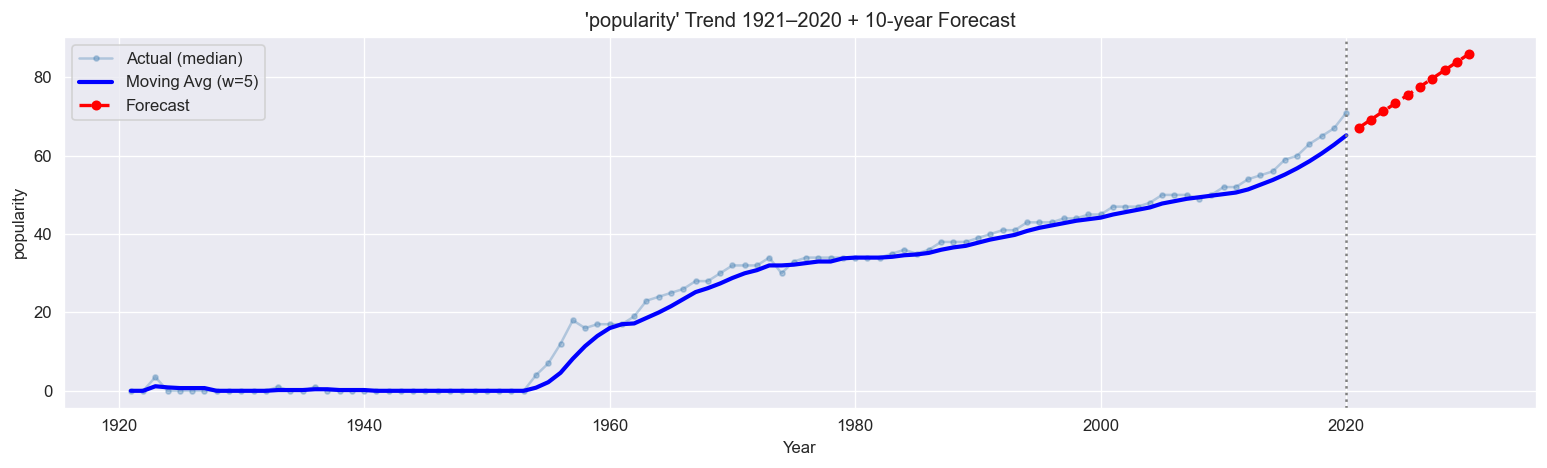

Forecast for 'popularity':
  2021: 67.1000
  2022: 69.2000
  2023: 71.3000
  2024: 73.4000
  2025: 75.5000
  2026: 77.6000
  2027: 79.7000
  2028: 81.8000
  2029: 83.9000
  2030: 86.0000


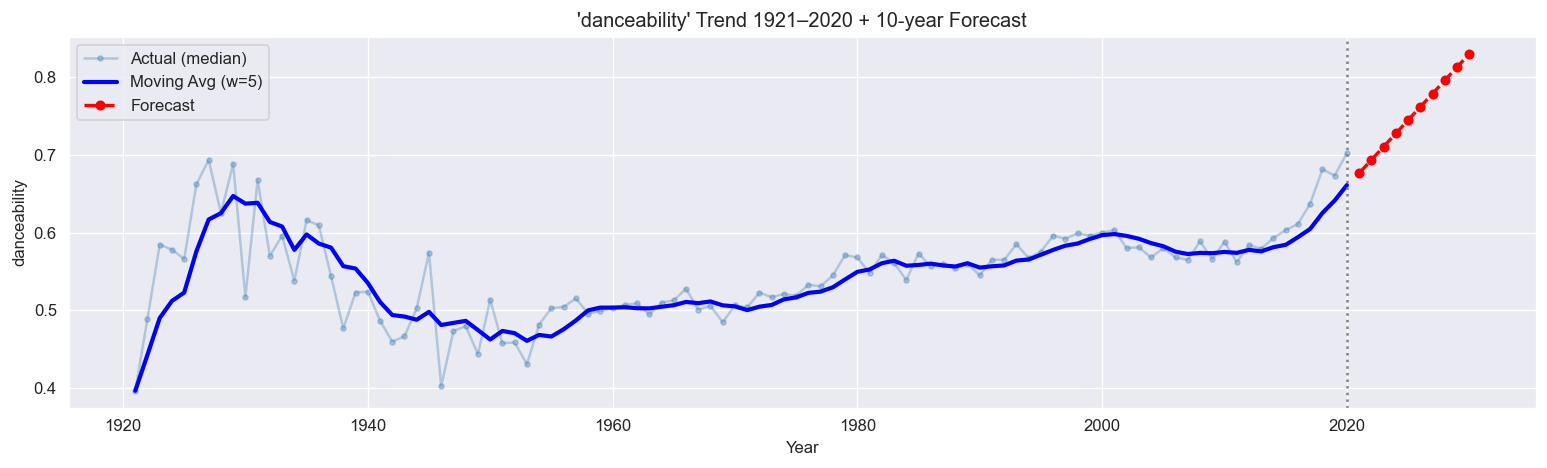

Forecast for 'danceability':
  2021: 0.6761
  2022: 0.6931
  2023: 0.7101
  2024: 0.7271
  2025: 0.7441
  2026: 0.7611
  2027: 0.7781
  2028: 0.7951
  2029: 0.8121
  2030: 0.8291


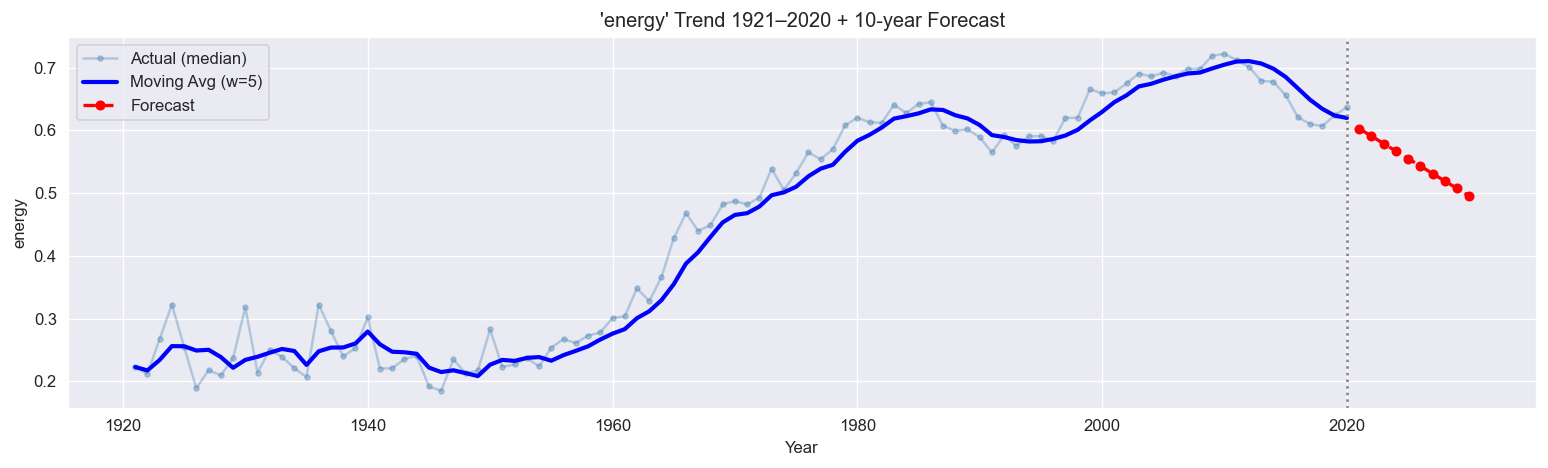

Forecast for 'energy':
  2021: 0.6029
  2022: 0.5909
  2023: 0.5790
  2024: 0.5671
  2025: 0.5551
  2026: 0.5432
  2027: 0.5313
  2028: 0.5194
  2029: 0.5074
  2030: 0.4955


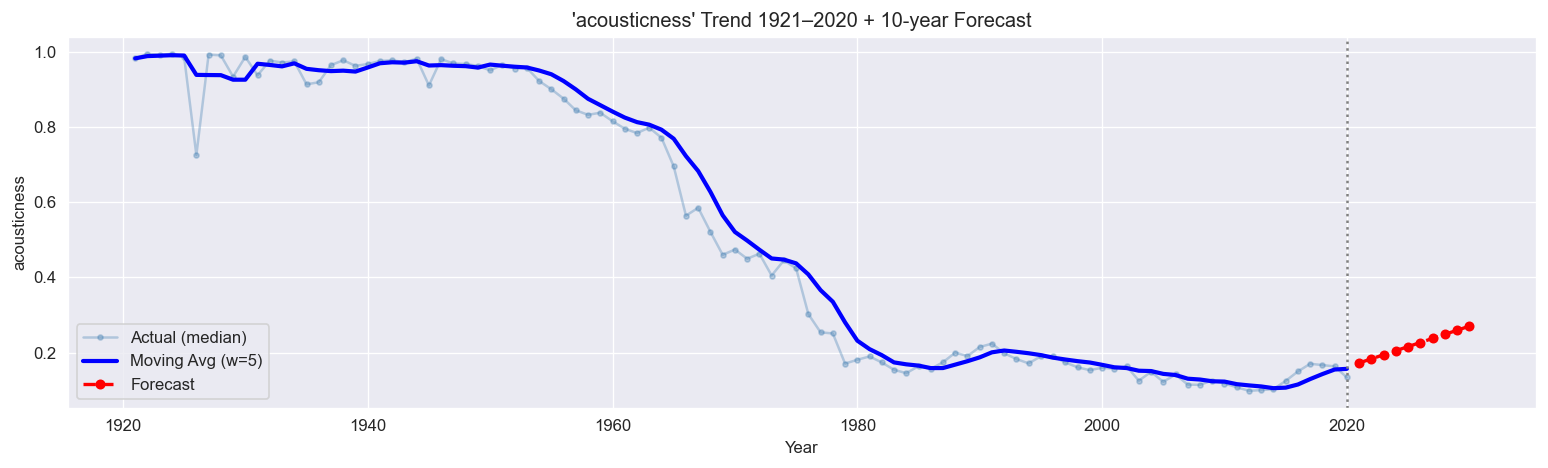

Forecast for 'acousticness':
  2021: 0.1727
  2022: 0.1835
  2023: 0.1944
  2024: 0.2052
  2025: 0.2161
  2026: 0.2270
  2027: 0.2378
  2028: 0.2487
  2029: 0.2595
  2030: 0.2704


In [46]:
def moving_average_forecast(df_year, feature="popularity", window=5, future=10):
    series = df_year[["year", feature]].sort_values("year")
    series = series.copy()
    series["smoothed"] = series[feature].rolling(window=window, min_periods=1).mean()

    last_n = series.tail(window)
    slope  = np.polyfit(last_n["year"], last_n["smoothed"], 1)
    fut_years = np.arange(series["year"].max() + 1,
                          series["year"].max() + future + 1)
    fut_vals  = np.polyval(slope, fut_years)

    plt.figure(figsize=(13, 4))
    plt.plot(series["year"], series[feature], "o-",
             alpha=0.35, color="steelblue", label="Actual (median)", markersize=3)
    plt.plot(series["year"], series["smoothed"], "-",
             color="blue", linewidth=2.5, label=f"Moving Avg (w={window})")
    plt.plot(fut_years, fut_vals, "r--o",
             linewidth=2, markersize=5, label="Forecast")
    plt.axvline(x=2020, color="gray", linestyle=":", linewidth=1.5)
    plt.title(f"'{feature}' Trend 1921–2020 + {future}-year Forecast", fontsize=12)
    plt.xlabel("Year")
    plt.ylabel(feature)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Forecast for '{feature}':")
    for yr, val in zip(fut_years, fut_vals):
        print(f"  {yr}: {val:.4f}")


for feat in ["popularity", "danceability", "energy", "acousticness"]:
    moving_average_forecast(df_year, feature=feat, window=5)

14:55:16 - cmdstanpy - INFO - Chain [1] start processing
14:55:16 - cmdstanpy - INFO - Chain [1] done processing


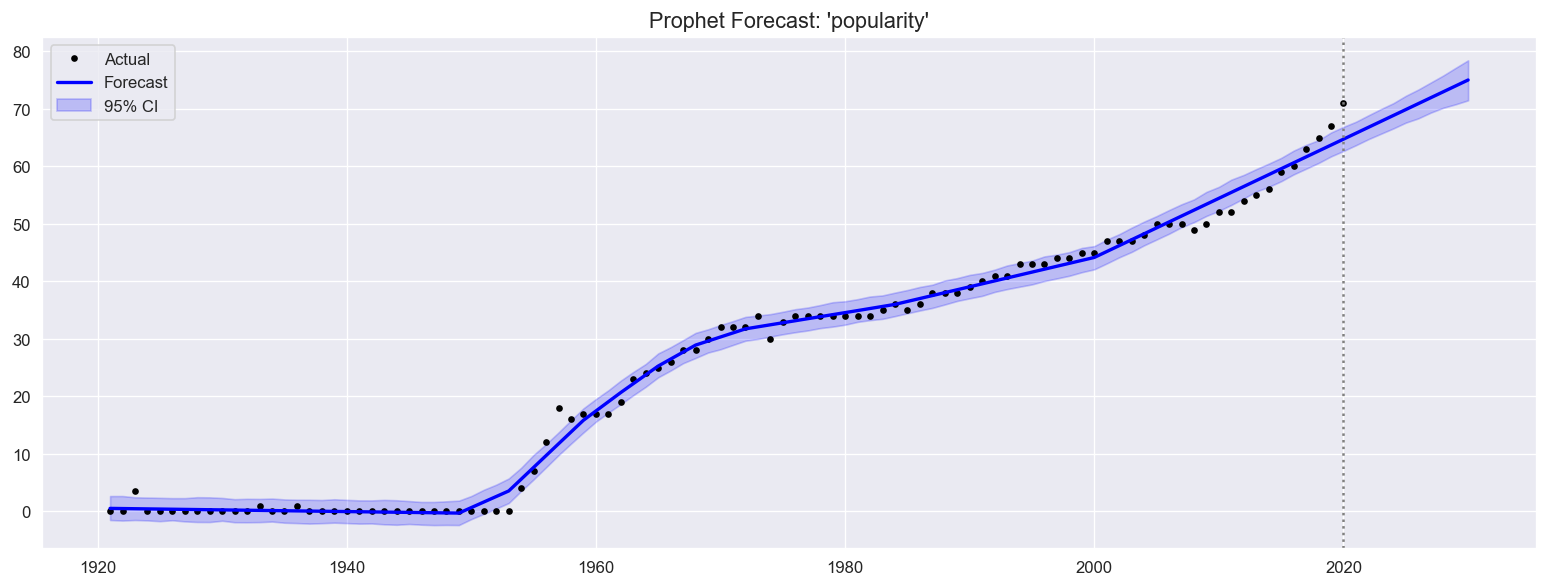

,year,forecast,lower,upper
0,2021,65.7559,63.6716,67.7521
1,2022,66.7836,64.7217,68.8652
2,2023,67.8113,65.6580,69.9506
3,2024,68.8390,66.5861,70.9746
4,2025,69.8695,67.5953,72.2576
5,2026,70.8972,68.3322,73.3431
6,2027,71.9249,69.3316,74.5642
7,2028,72.9526,70.1716,75.7800
8,2029,73.9831,70.7854,77.1205
9,2030,75.0107,71.4745,78.4304


In [47]:
# ── Prophet forecast ─────────────────────────────────────────
from prophet import Prophet

def prophet_forecast(df_year, feature="popularity", periods=10):
    df_p = df_year[["year", feature]].rename(
        columns={"year": "ds", feature: "y"})
    df_p["ds"] = pd.to_datetime(df_p["ds"], format="%Y")

    model = Prophet(yearly_seasonality=False,
                    weekly_seasonality=False,
                    daily_seasonality=False,
                    changepoint_prior_scale=0.3)
    model.fit(df_p)

    future   = model.make_future_dataframe(periods=periods, freq="YS")
    forecast = model.predict(future)

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(df_p["ds"], df_p["y"], "ko", markersize=3, label="Actual")
    ax.plot(forecast["ds"], forecast["yhat"], "b-", linewidth=2, label="Forecast")
    ax.fill_between(forecast["ds"],
                    forecast["yhat_lower"],
                    forecast["yhat_upper"],
                    alpha=0.2, color="blue", label="95% CI")
    ax.axvline(x=pd.Timestamp("2020"), color="gray", linestyle=":")
    ax.set_title(f"Prophet Forecast: '{feature}'", fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

    result = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(periods).copy()
    result["ds"] = result["ds"].dt.year
    result.columns = ["year", "forecast", "lower", "upper"]
    display(result.round(4).reset_index(drop=True))


prophet_forecast(df_year, feature="popularity", periods=10)

## 📋 Step 9: Evaluation

In [48]:
# ── KNN: test on 5 random well-known songs ────────────────────
print("KNN Evaluation — Top 3 recommendations per query")
print("=" * 60)
test = df_scaled[df_scaled["popularity"] > 60].sample(5, random_state=42)

for _, song in test.iterrows():
    recs = recommend_songs(song["name"], df_scaled, knn_model, n=3)
    if recs is not None:
        for i, row in recs.iterrows():
            print(f"    {i+1}. {row['name']} — {row['artists_clean']} "
                  f"(sim: {row['similarity_score']:.4f})")

KNN Evaluation — Top 3 recommendations per query

🎧 Query  : 'Una Vez'
   Artist : Bad Bunny, Mora
   Year   : 2020
   Pop    : 80
-------------------------------------------------------
    1. Cats In The Cradle — Ugly Kid Joe (sim: 0.9981)
    2. You're Beginning to Get to Me — Clay Walker (sim: 0.9979)
    3. Stars — Kindred The Family Soul (sim: 0.9979)

🎧 Query  : 'Thong Song'
   Artist : Sisqo
   Year   : 1999
   Pop    : 67
-------------------------------------------------------
    1. In Your Eyes — Kylie Minogue (sim: 0.9998)
    2. I Cannot Believe It's True - 2016 Remaster — Phil Collins (sim: 0.9996)
    3. Promises, Promises - US Single Version / 2018 Remaster — Naked Eyes (sim: 0.9994)

🎧 Query  : 'Something About You - Single Version'
   Artist : Level 42
   Year   : 1989
   Pop    : 61
-------------------------------------------------------
    1. In My House - Single Version — Mary Jane Girls (sim: 0.9995)
    2. Little Walter — Tony! Toni! Toné! (sim: 0.9994)
    3. I

In [49]:
# ── Cluster: top 3 popular songs per cluster ──────────────────
print("Cluster Evaluation — Top 3 Songs Per Cluster")
print("=" * 60)

for cid in sorted(df_clustered["cluster"].unique()):
    top = (df_clustered[
        (df_clustered["cluster"] == cid) & (df_clustered["popularity"] > 0)
    ].sort_values("popularity", ascending=False).head(3))

    print(f"\n  Cluster {cid}:")
    for _, row in top.iterrows():
        print(f"    • {row['name']} by {row['artists_clean']} "
              f"(pop: {row['popularity']})")

Cluster Evaluation — Top 3 Songs Per Cluster

  Cluster 0:
    • Dakiti by Bad Bunny, Jhay Cortez (pop: 100)
    • Mood (feat. iann dior) by 24kGoldn, iann dior (pop: 99)
    • Dynamite by BTS (pop: 97)

  Cluster 1:
    • everything i wanted by Billie Eilish (pop: 87)
    • Buttercup by Jack Stauber (pop: 80)
    • Ribs by Lorde (pop: 77)

  Cluster 2:
    • you broke me first by Tate McRae (pop: 95)
    • Lonely (with benny blanco) by Justin Bieber, benny blanco (pop: 95)
    • Heather by Conan Gray (pop: 93)

  Cluster 3:
    • What You Know Bout Love by Pop Smoke (pop: 96)
    • Parce (feat. Justin Quiles) by Maluma, Lenny Tavárez, Justin Quiles (pop: 91)
    • Ay, DiOs Mío! by KAROL G (pop: 91)

  Cluster 4:
    • Eyes Blue Like The Atlantic (feat. Subvrbs) by Sista Prod, Subvrbs (pop: 83)
    • Skit by BTS (pop: 79)
    • Freak (feat. REI AMI) by Sub Urban, REI AMI (pop: 78)


## 💾 Step 10: Save & Download Models

In [50]:
import os
os.makedirs("saved_models", exist_ok=True)

joblib.dump(knn_model,    "saved_models/knn_model.pkl")
joblib.dump(kmeans_model, "saved_models/kmeans_model.pkl")
joblib.dump(scaler,       "saved_models/scaler.pkl")
df_clustered.to_csv("saved_models/df_clustered.csv", index=False)

print("✅ Saved:")
print(os.listdir("saved_models"))

✅ Saved:
['df_clustered.csv', 'kmeans_model.pkl', 'knn_model.pkl', 'scaler.pkl']


In [54]:
import shutil
from google.colab import files

shutil.make_archive("spotify_models", "zip", "saved_models")
files.download("spotify_models.zip")
print("✅ Download started!")

ModuleNotFoundError: No module named 'google'

## 🎮 Step 11: Interactive Widget

In [62]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---------------- UI COMPONENTS ---------------- #

song_input = widgets.Text(
    value="Shape of You",
    description="🎵 Song:",
    layout=widgets.Layout(width="400px")
)

model_toggle = widgets.RadioButtons(
    options=["KNN (Audio Similarity)", "K-Means (Cluster)"],
    description="Model:"
)

popular_toggle = widgets.Checkbox(
    value=True,
    description="Popular songs only (exclude popularity=0)"
)

n_slider = widgets.IntSlider(
    value=10, min=1, max=20, description="# Recs:"
)

button = widgets.Button(
    description="🔍 Recommend",
    button_style="success",
    layout=widgets.Layout(width="180px", height="38px")
)

output = widgets.Output()

# ---------------- DEBUG FUNCTION ---------------- #

def on_click(b):
    with output:
        clear_output(wait=True)

        print("🚀 Button clicked")

        # Get inputs
        song = song_input.value.strip()
        n    = n_slider.value
        pop  = popular_toggle.value

        print(f"🎵 Input Song: {song}")
        print(f"🔢 Number of recommendations: {n}")
        print(f"⭐ Popular only: {pop}")
        print(f"🤖 Selected Model: {model_toggle.value}")

        try:
            # ---------------- MODEL SELECTION ---------------- #

            if "KNN" in model_toggle.value:
                print("➡️ Using KNN model...")

                recs = recommend_songs(
                    song, df_scaled, knn_model,
                    n=n, popular_only=pop
                )

                print("✅ Function executed")

                if recs is None:
                    print("❌ No recommendations returned (None)")
                else:
                    print(f"📊 Recommendations shape: {recs.shape}")
                    print("🔍 Preview:")
                    print(recs.head())

                    # Try styled display
                    try:
                        display(recs.style.background_gradient(
                            subset=["similarity_score"],
                            cmap="Greens"
                        ))
                    except Exception as e:
                        print("⚠️ Styling failed:", e)
                        print("➡️ Showing raw dataframe instead")
                        display(recs)

            else:
                print("➡️ Using K-Means model...")

                recs = recommend_from_cluster(
                    song, df_clustered,
                    n=n, popular_only=pop
                )

                print("✅ Function executed")

                if recs is None:
                    print("❌ No recommendations returned (None)")
                else:
                    print(f"📊 Recommendations shape: {recs.shape}")
                    print("🔍 Preview:")
                    print(recs.head())

                    # Try styled display
                    try:
                        display(recs.style.background_gradient(
                            subset=["popularity"],
                            cmap="Purples"
                        ))
                    except Exception as e:
                        print("⚠️ Styling failed:", e)
                        print("➡️ Showing raw dataframe instead")
                        display(recs)

        except Exception as e:
            print("🔥 ERROR OCCURRED:")
            print(type(e).__name__, ":", e)

# ---------------- BUTTON EVENT ---------------- #

button.on_click(on_click)

# ---------------- DISPLAY UI ---------------- #

display(widgets.VBox([
    song_input,
    model_toggle,
    popular_toggle,
    n_slider,
    button,
    output
]))